<a href="https://colab.research.google.com/github/jadlm3407/AgenticFlow/blob/main/Prediccion_mundiales_eliminatorias_1_(gemini).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Celda 1: Importar repositorios y librerías iniciales
!git clone https://github.com/martj42/international_results.git

import pandas as pd

# Cargar los datos principales en DataFrames de Pandas
df_results = pd.read_csv('/content/international_results/results.csv')
df_shootouts = pd.read_csv('/content/international_results/shootouts.csv')
df_goalscorers = pd.read_csv('/content/international_results/goalscorers.csv')

# Visualizar las primeras 5 filas del dataset principal para confirmar que cargó bien
df_results.head()

fatal: destination path 'international_results' already exists and is not an empty directory.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
# Celda 2: Configuración de la predicción y limpieza de datos

# 1. Configuración: Los equipos del partido a predecir
equipo_1 = 'Argentina'
equipo_2 = 'Switzerland'

# 2. Limpieza y conversión de tipos
# Convertimos la columna 'date' a formato datetime de Pandas para poder operar con años
df_results['date'] = pd.to_datetime(df_results['date'])

# 3. Filtrado: Nos quedamos solo con los partidos desde el año 2018
df_historico = df_results[df_results['date'].dt.year >= 2018].copy()

# Eliminamos posibles valores nulos que puedan dar error al entrenar el modelo
df_historico = df_historico.dropna()

# Reseteamos el índice de la tabla para que sea continuo tras descartar las filas antiguas
df_historico.reset_index(drop=True, inplace=True)

# Comprobamos con cuántos datos nos hemos quedado para entrenar
print(f"Total de partidos disponibles para el modelo (desde 2018): {len(df_historico)}")
display(df_historico.head())

Total de partidos disponibles para el modelo (desde 2018): 8204


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2018-01-02,Iraq,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
1,2018-01-02,Oman,Bahrain,1.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
2,2018-01-05,Oman,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
3,2018-01-07,Estonia,Sweden,1.0,1.0,Friendly,Abu Dhabi,United Arab Emirates,True
4,2018-01-11,Denmark,Sweden,0.0,1.0,Friendly,Abu Dhabi,United Arab Emirates,True


In [ ]:
# Celda 3: Cálculo de Fuerza Ofensiva y Defensiva (Modelo de Poisson / Dixon-Coles)
import statsmodels.formula.api as smf
import pandas as pd

# 1. Reestructurar los datos: necesitamos una fila por cada equipo por partido
# Extraemos los datos desde la perspectiva del equipo local
df_home = df_historico[['home_team', 'away_team', 'home_score', 'neutral']].copy()
df_home = df_home.rename(columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goals'})
df_home['venue'] = 'home'

# Extraemos los datos desde la perspectiva del equipo visitante
df_away = df_historico[['away_team', 'home_team', 'away_score', 'neutral']].copy()
df_away = df_away.rename(columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goals'})
df_away['venue'] = 'away'

# Combinamos ambos dataframes
df_poisson = pd.concat([df_home, df_away], ignore_index=True)

# Ajustamos la ventaja de campo: si el partido es neutral, lo marcamos
df_poisson.loc[df_poisson['neutral'] == True, 'venue'] = 'neutral'

# 2. Entrenar el modelo
# Le decimos que los 'goles' dependen de quién ataca ('team'), quién defiende ('opponent') y si juegan en casa ('venue')
print("Entrenando el modelo de Poisson (Dixon-Coles)...")
modelo_dixon_coles = smf.poisson(formula="goals ~ team + opponent + venue", data=df_poisson).fit(disp=False)

# 3. Función para extraer las fuerzas ofensivas y defensivas del modelo
def obtener_fuerzas(equipo):
    # Statsmodels usa al primer equipo alfabéticamente como referencia (valor 0).
    # Con `.get()` evitamos errores si el equipo buscado es justo el de referencia o si no existe
    ataque = modelo_dixon_coles.params.get(f'team[T.{equipo}]', 0.0)
    defensa = modelo_dixon_coles.params.get(f'opponent[T.{equipo}]', 0.0)
    return ataque, defensa

# 4. Probamos con los equipos que configuraste en la celda 2
atk_eq1, def_eq1 = obtener_fuerzas(equipo_1)
atk_eq2, def_eq2 = obtener_fuerzas(equipo_2)

print("\n--- Estadísticas estimadas del Modelo ---")
print(f"{equipo_1}: Fuerza Ofensiva = {atk_eq1:.4f} | Vulnerabilidad Defensiva = {def_eq1:.4f}")
print(f"{equipo_2}: Fuerza Ofensiva = {atk_eq2:.4f} | Vulnerabilidad Defensiva = {def_eq2:.4f}")
print("\n* NOTA: En Fuerza Ofensiva, cuanto más alto (positivo), más goles anota.")
print("* NOTA: En Vulnerabilidad Defensiva, cuanto más bajo (negativo), menos goles recibe.")

Entrenando el modelo de Poisson (Dixon-Coles)...

--- Estadísticas estimadas del Modelo ---
Argentina: Fuerza Ofensiva = 2.4628 | Vulnerabilidad Defensiva = -2.0061
Switzerland: Fuerza Ofensiva = 2.3093 | Vulnerabilidad Defensiva = -1.5542

* NOTA: En Fuerza Ofensiva, cuanto más alto (positivo), más goles anota.
* NOTA: En Vulnerabilidad Defensiva, cuanto más bajo (negativo), menos goles recibe.


Entrenando modelos para Argentina vs Switzerland...


 🏆 PREDICCIÓN FINAL DEL MODELO 🏆
🥇 GANADOR GLOBAL: Argentina
⚽ MARCADOR (90 min): Argentina 1 - 0 Switzerland
🎯 ¿SE VA A PENALES?: NO. Argentina ganará directamente en los 90 minutos reglamentarios.



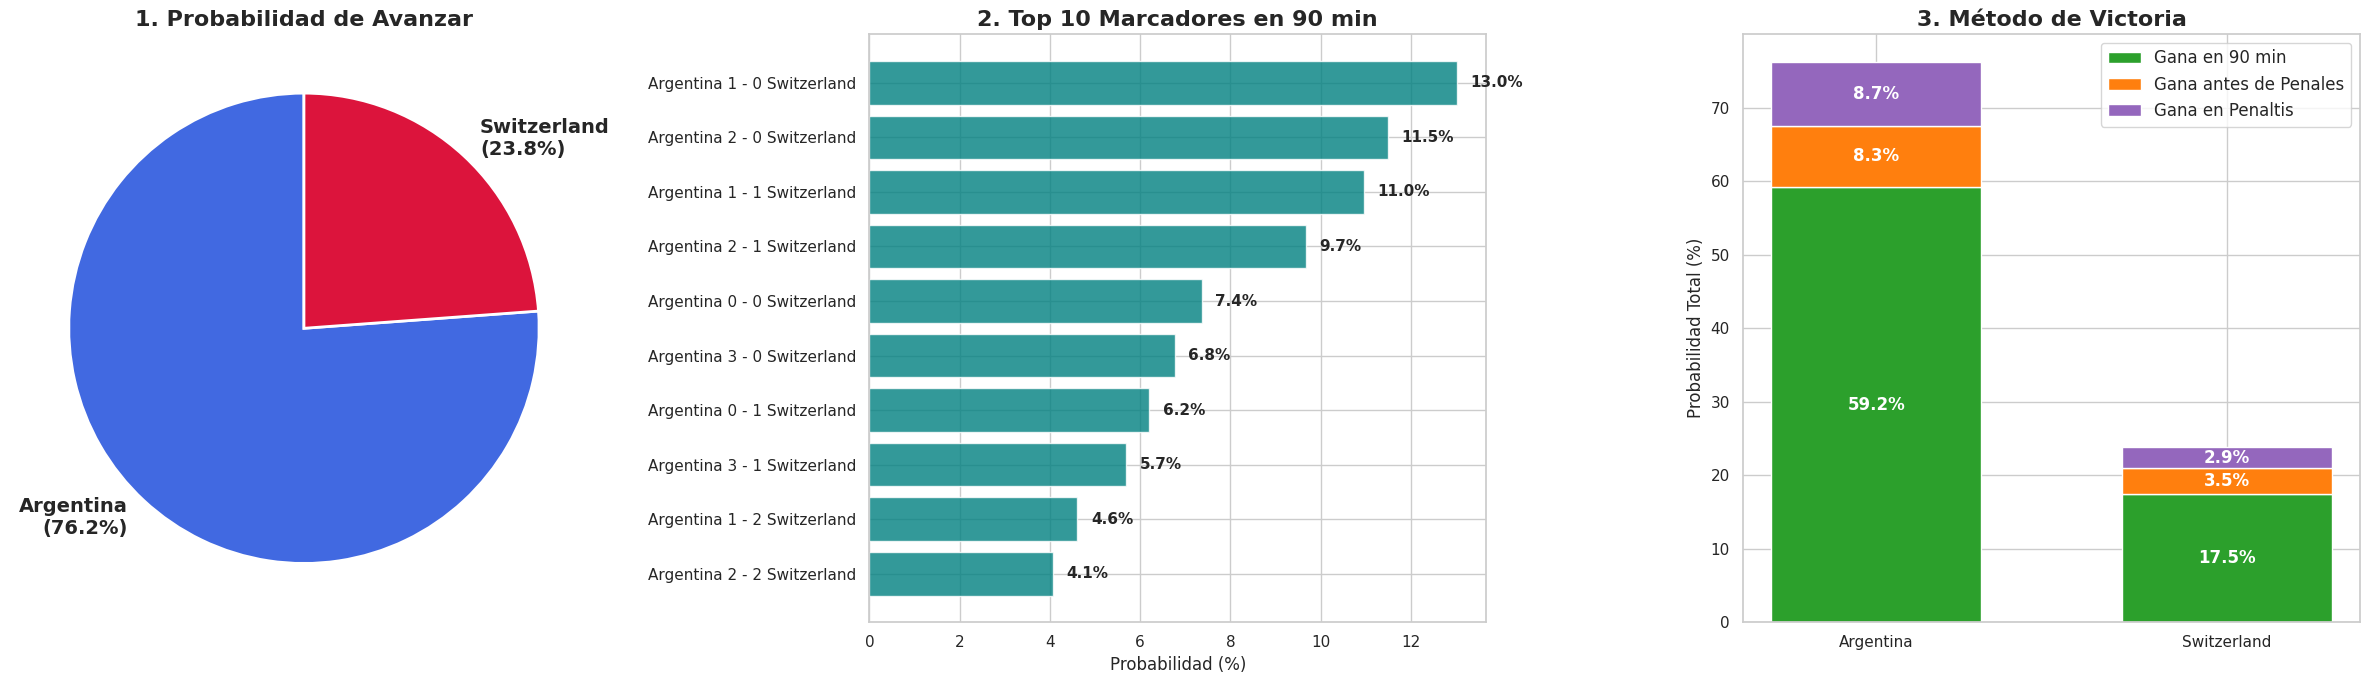

In [ ]:
# Celda 4 (VERSIÓN FINAL): XGBoost + Monte Carlo + 3 Gráficas + Predicción de Penales Directa
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f"Entrenando modelos para {equipo_1} vs {equipo_2}...\n")

# ==========================================
# MODELO 1: GOLES ESPERADOS (XGBRegressor)
# ==========================================
df_xgb = df_poisson.copy()
df_xgb['team'] = df_xgb['team'].astype('category')
df_xgb['opponent'] = df_xgb['opponent'].astype('category')
df_xgb['venue'] = df_xgb['venue'].astype('category')

X_goals = df_xgb[['team', 'opponent', 'venue']]
y_goals = df_xgb['goals']

xgb_goals = xgb.XGBRegressor(objective='count:poisson', tree_method='hist', enable_categorical=True, n_estimators=100, learning_rate=0.1, random_state=42)
xgb_goals.fit(X_goals, y_goals)

match_data = pd.DataFrame({'team': [equipo_1, equipo_2], 'opponent': [equipo_2, equipo_1], 'venue': ['neutral', 'neutral']})
match_data['team'] = match_data['team'].astype(X_goals['team'].dtypes)
match_data['opponent'] = match_data['opponent'].astype(X_goals['opponent'].dtypes)
match_data['venue'] = match_data['venue'].astype(X_goals['venue'].dtypes)

xG_pred = xgb_goals.predict(match_data)
xG_eq1, xG_eq2 = xG_pred[0], xG_pred[1]

# ==========================================
# MODELO 2: TANDAS DE PENALTIS (XGBClassifier)
# ==========================================
pen_home = df_shootouts[['home_team', 'away_team', 'winner']].copy()
pen_home.columns = ['team', 'opponent', 'winner']
pen_away = df_shootouts[['away_team', 'home_team', 'winner']].copy()
pen_away.columns = ['team', 'opponent', 'winner']

df_pen = pd.concat([pen_home, pen_away], ignore_index=True)
df_pen['won'] = (df_pen['team'] == df_pen['winner']).astype(int)

X_pen = df_pen[['team', 'opponent']]
y_pen = df_pen['won']
X_pen['team'] = X_pen['team'].astype('category')
X_pen['opponent'] = X_pen['opponent'].astype('category')

xgb_pen = xgb.XGBClassifier(tree_method='hist', enable_categorical=True, n_estimators=50, learning_rate=0.05, random_state=42)
xgb_pen.fit(X_pen, y_pen)

match_pen = pd.DataFrame({'team': [equipo_1], 'opponent': [equipo_2]})
match_pen['team'] = match_pen['team'].astype(X_pen['team'].dtypes)
match_pen['opponent'] = match_pen['opponent'].astype(X_pen['opponent'].dtypes)

try:
    prob_pen_eq1 = xgb_pen.predict_proba(match_pen)[0][1]
except:
    prob_pen_eq1 = 0.5
prob_pen_eq2 = 1.0 - prob_pen_eq1

# ==========================================
# SIMULACIÓN MONTE CARLO Y MATRIZ POISSON
# ==========================================
n_sim = 100000

# 1. Simulación Eliminatorias
sim_90_eq1 = np.random.poisson(xG_eq1, n_sim)
sim_90_eq2 = np.random.poisson(xG_eq2, n_sim)
vic_90_eq1 = np.sum(sim_90_eq1 > sim_90_eq2)
vic_90_eq2 = np.sum(sim_90_eq2 > sim_90_eq1)
empates_90 = sim_90_eq1 == sim_90_eq2
n_empates_90 = np.sum(empates_90)

xG_et_eq1, xG_et_eq2 = xG_eq1 / 3, xG_eq2 / 3
sim_et_eq1 = np.random.poisson(xG_et_eq1, n_empates_90)
sim_et_eq2 = np.random.poisson(xG_et_eq2, n_empates_90)
vic_et_eq1 = np.sum(sim_et_eq1 > sim_et_eq2)
vic_et_eq2 = np.sum(sim_et_eq2 > sim_et_eq1)
empates_et = sim_et_eq1 == sim_et_eq2
n_penaltis = np.sum(empates_et)

sim_pen = np.random.rand(n_penaltis) < prob_pen_eq1
vic_pen_eq1 = np.sum(sim_pen)
vic_pen_eq2 = n_penaltis - vic_pen_eq1

prob_clasifica_eq1 = (vic_90_eq1 + vic_et_eq1 + vic_pen_eq1) / n_sim * 100
prob_clasifica_eq2 = (vic_90_eq2 + vic_et_eq2 + vic_pen_eq2) / n_sim * 100
desglose_eq1 = [vic_90_eq1/n_sim*100, vic_et_eq1/n_sim*100, vic_pen_eq1/n_sim*100]
desglose_eq2 = [vic_90_eq2/n_sim*100, vic_et_eq2/n_sim*100, vic_pen_eq2/n_sim*100]

# 2. Matriz de Resultados (para sacar el Top Marcadores)
max_goles = 6
goles_rango = np.arange(0, max_goles)
prob_goles_eq1 = poisson.pmf(goles_rango, xG_eq1)
prob_goles_eq2 = poisson.pmf(goles_rango, xG_eq2)
matriz_probabilidades = np.outer(prob_goles_eq1, prob_goles_eq2)

flat_probs = matriz_probabilidades.flatten()
top_10_idx = np.argsort(flat_probs)[-10:][::-1]

top_10_scores = []
top_10_probs = []
for idx in top_10_idx:
    g1 = idx // max_goles
    g2 = idx % max_goles
    top_10_scores.append(f'{equipo_1} {g1} - {g2} {equipo_2}')
    top_10_probs.append(flat_probs[idx] * 100)

top_10_scores.reverse()
top_10_probs.reverse()

# ==========================================
# 3. EXTRACCIÓN DE LA PREDICCIÓN FINAL EN TEXTO
# ==========================================
ganador_global = equipo_1 if prob_clasifica_eq1 > prob_clasifica_eq2 else equipo_2

prob_1_90 = desglose_eq1[0]
prob_X_90 = n_empates_90 / n_sim * 100
prob_2_90 = desglose_eq2[0]

matriz_filtrada = matriz_probabilidades.copy()

if prob_1_90 > prob_X_90 and prob_1_90 > prob_2_90:
    escenario_90 = equipo_1
    mask = np.tril(np.ones((max_goles, max_goles), dtype=bool), -1)
elif prob_2_90 > prob_X_90 and prob_2_90 > prob_1_90:
    escenario_90 = equipo_2
    mask = np.triu(np.ones((max_goles, max_goles), dtype=bool), 1)
else:
    escenario_90 = "Empate"
    mask = np.eye(max_goles, dtype=bool)

matriz_filtrada[~mask] = 0
idx_max = np.argmax(matriz_filtrada)
goles_pred_eq1 = idx_max // max_goles
goles_pred_eq2 = idx_max % max_goles

# Lógica exclusiva para responder a la duda de penales
if escenario_90 == "Empate":
    # Comparamos si es estadísticamente más probable que un equipo rompa el empate antes o que lleguen al final
    resueltos_antes = vic_et_eq1 + vic_et_eq2
    if n_penaltis > resueltos_antes:
        ganador_penales = equipo_1 if vic_pen_eq1 > vic_pen_eq2 else equipo_2
        txt_penales = f"SÍ. El partido se decidirá en penales y el ganador de la tanda será {ganador_penales}."
    else:
        txt_penales = f"NO. {ganador_global} logrará ganar el partido antes de que se llegue a la tanda de penales."
else:
    txt_penales = f"NO. {escenario_90} ganará directamente en los 90 minutos reglamentarios."

print("\n" + "="*60)
print(" 🏆 PREDICCIÓN FINAL DEL MODELO 🏆")
print("="*60)
print(f"🥇 GANADOR GLOBAL: {ganador_global}")
print(f"⚽ MARCADOR (90 min): {equipo_1} {goles_pred_eq1} - {goles_pred_eq2} {equipo_2}")
print(f"🎯 ¿SE VA A PENALES?: {txt_penales}")
print("="*60 + "\n")

# ==========================================
# VISUALIZACIÓN: LAS 3 GRÁFICAS CLAVE
# ==========================================
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(24, 7))

# 1. Gráfica Global: ¿Quién Avanza?
labels = [f'{equipo_1}\n({prob_clasifica_eq1:.1f}%)', f'{equipo_2}\n({prob_clasifica_eq2:.1f}%)']
sizes = [prob_clasifica_eq1, prob_clasifica_eq2]
axs[0].pie(sizes, labels=labels, colors=['royalblue', 'crimson'], autopct='', startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 14, 'weight': 'bold'})
axs[0].set_title('1. Probabilidad de Avanzar', fontsize=16, fontweight='bold')

# 2. Top Resultados Exactos (90 min)
barras_top = axs[1].barh(top_10_scores, top_10_probs, color='teal', alpha=0.8)
axs[1].set_title('2. Top 10 Marcadores en 90 min', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Probabilidad (%)', fontsize=12)
for i, barra in enumerate(barras_top):
    ancho = barra.get_width()
    axs[1].text(ancho + 0.3, barra.get_y() + barra.get_height()/2, f'{ancho:.1f}%', va='center', fontsize=11, fontweight='bold')

# 3. Desglose del Método de Victoria
etiquetas_barras = [equipo_1, equipo_2]
p_90 = np.array([desglose_eq1[0], desglose_eq2[0]])
p_et = np.array([desglose_eq1[1], desglose_eq2[1]])
p_pen = np.array([desglose_eq1[2], desglose_eq2[2]])

ancho_barra = 0.6
axs[2].bar(etiquetas_barras, p_90, ancho_barra, label='Gana en 90 min', color='#2ca02c')
axs[2].bar(etiquetas_barras, p_et, ancho_barra, bottom=p_90, label='Gana antes de Penales', color='#ff7f0e')
axs[2].bar(etiquetas_barras, p_pen, ancho_barra, bottom=p_90+p_et, label='Gana en Penaltis', color='#9467bd')

axs[2].set_title('3. Método de Victoria', fontsize=16, fontweight='bold')
axs[2].set_ylabel('Probabilidad Total (%)', fontsize=12)
axs[2].legend(fontsize=12)

for i in range(2):
    axs[2].text(i, p_90[i]/2, f"{p_90[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold')
    if p_et[i] > 1: axs[2].text(i, p_90[i] + p_et[i]/2, f"{p_et[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold')
    if p_pen[i] > 1: axs[2].text(i, p_90[i] + p_et[i] + p_pen[i]/2, f"{p_pen[i]:.1f}%", ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()